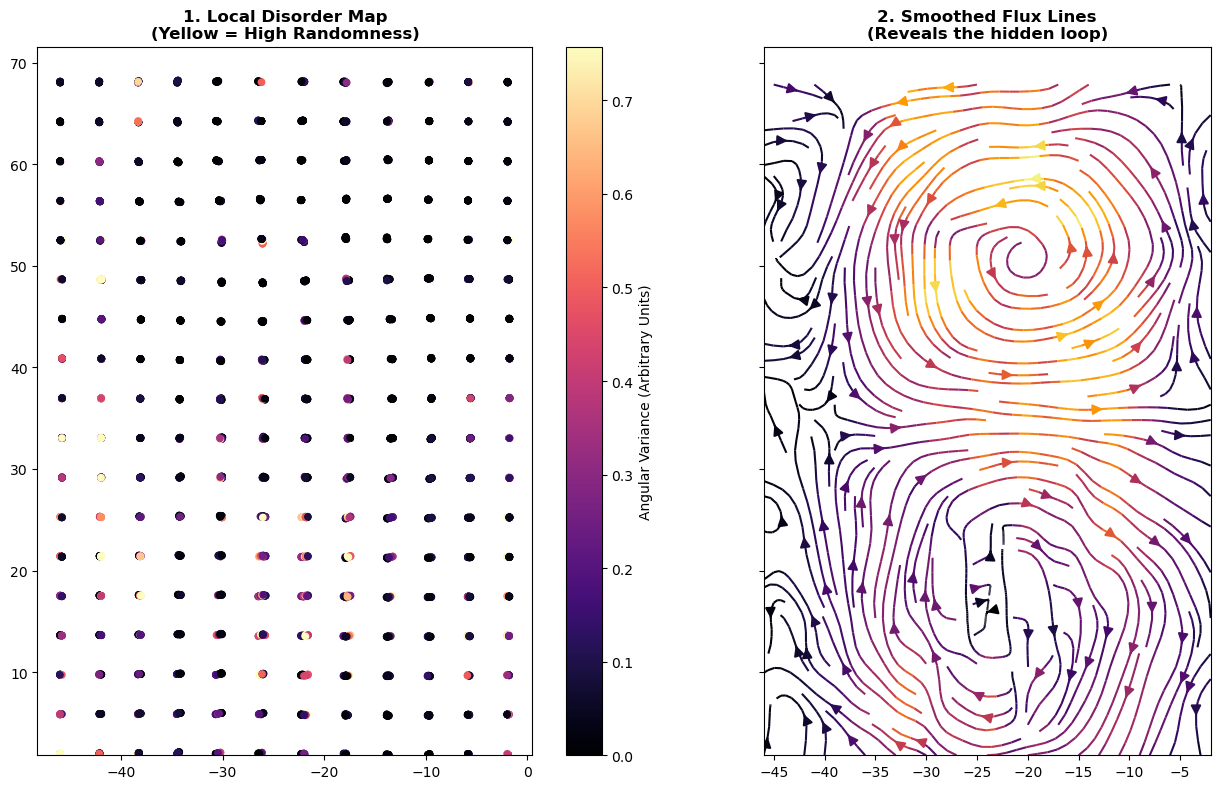

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ase.io
from scipy.spatial import KDTree
from scipy.interpolate import griddata

# ==========================================
# --- 1. LOAD DATA ---
# ==========================================
filename = 'PTO6_STO6_18_18_labyrinthPoscar.vasp'
atoms = ase.io.read(filename)
atoms.rotate(-90, 'y', rotate_cell=True) 
atoms.wrap()
pos = atoms.positions
syms = np.array(atoms.get_chemical_symbols())

pos_Ti = pos[syms == 'Ti']
pos_O  = pos[syms == 'O']

# Calculate Vectors (Ti vs O - The Physics)
tree_O = KDTree(pos_O[:, :2])
vectors = []
plot_pos = []

for ti in pos_Ti:
    ti_2d = ti[:2]
    dists, ind = tree_O.query(ti_2d, k=4)
    if np.mean(dists) > 2.8: continue
    center_O = np.mean(pos_O[ind, :2], axis=0)
    vectors.append(ti_2d - center_O)
    plot_pos.append(ti_2d)

vectors = np.array(vectors)
plot_pos = np.array(plot_pos)

# ==========================================
# --- 2. QUANTIFY THE "RANDOMNESS" ---
# ==========================================
# We calculate "Local Angular Disorder"
# For each arrow, how much does it deviate from its neighbors?
tree_Ti = KDTree(plot_pos)
disorder = []

for i, ti in enumerate(plot_pos):
    # Find 8 nearest neighbors
    dists, inds = tree_Ti.query(ti, k=9) # k=9 includes self
    neighbor_inds = inds[1:] # Exclude self
    
    # Get neighbor vectors
    v_self = vectors[i]
    v_neighbors = vectors[neighbor_inds]
    
    # Normalize
    v_self_u = v_self / np.linalg.norm(v_self)
    v_neigh_u = v_neighbors / np.linalg.norm(v_neighbors, axis=1)[:, None]
    
    # Calculate Dot Product (Cosine similarity)
    # 1.0 = Aligned, 0.0 = 90 deg, -1.0 = Opposite
    dots = np.dot(v_neigh_u, v_self_u)
    
    # Disorder metric: 0 = Perfect Order, 1 = Total Chaos
    local_disorder = np.mean(1.0 - dots)
    disorder.append(local_disorder)

disorder = np.array(disorder)

# ==========================================
# --- 3. PLOT ---
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

# Grid for Streamlines
gx, gy = np.mgrid[plot_pos[:,0].min():plot_pos[:,0].max():0.5, 
                  plot_pos[:,1].min():plot_pos[:,1].max():0.5]
U = griddata(plot_pos, vectors[:,0], (gx, gy), method='linear', fill_value=0)
V = griddata(plot_pos, vectors[:,1], (gx, gy), method='linear', fill_value=0)

# --- PANEL 1: THE DISORDER MAP ---
# Color = How "Random" is this area?
gx_scat, gy_scat = plot_pos[:,0], plot_pos[:,1]
limit = np.percentile(disorder, 95)

sc = axes[0].scatter(gx_scat, gy_scat, c=disorder, cmap='magma', s=20, vmin=0, vmax=limit)
axes[0].set_title("1. Local Disorder Map\n(Yellow = High Randomness)", fontweight='bold')
plt.colorbar(sc, ax=axes[0], label="Angular Variance (Arbitrary Units)")
axes[0].invert_yaxis()
axes[0].set_aspect('equal')

# --- PANEL 2: THE "SMOOTHED" FLUX ---
# We blur the arrows to show the "Average" flow hidden in the randomness
from scipy.ndimage import gaussian_filter
U_smooth = gaussian_filter(U, sigma=2) # Smoothing
V_smooth = gaussian_filter(V, sigma=2)
Mag_smooth = np.sqrt(U_smooth**2 + V_smooth**2)

strm = axes[1].streamplot(gx.T, gy.T, U_smooth.T, V_smooth.T, color=Mag_smooth.T, 
                          cmap='inferno', density=1.5, arrowsize=1.5)
axes[1].set_title("2. Smoothed Flux Lines\n(Reveals the hidden loop)", fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

Loading PTO6_STO6_18_18_labyrinthPoscar.vasp...
Calculating vectors...
Global Color Limit (Locked to Oxygen): +/- 1.544 Å
Generating Figure 1: TRUE PHYSICS (Ti-O)...


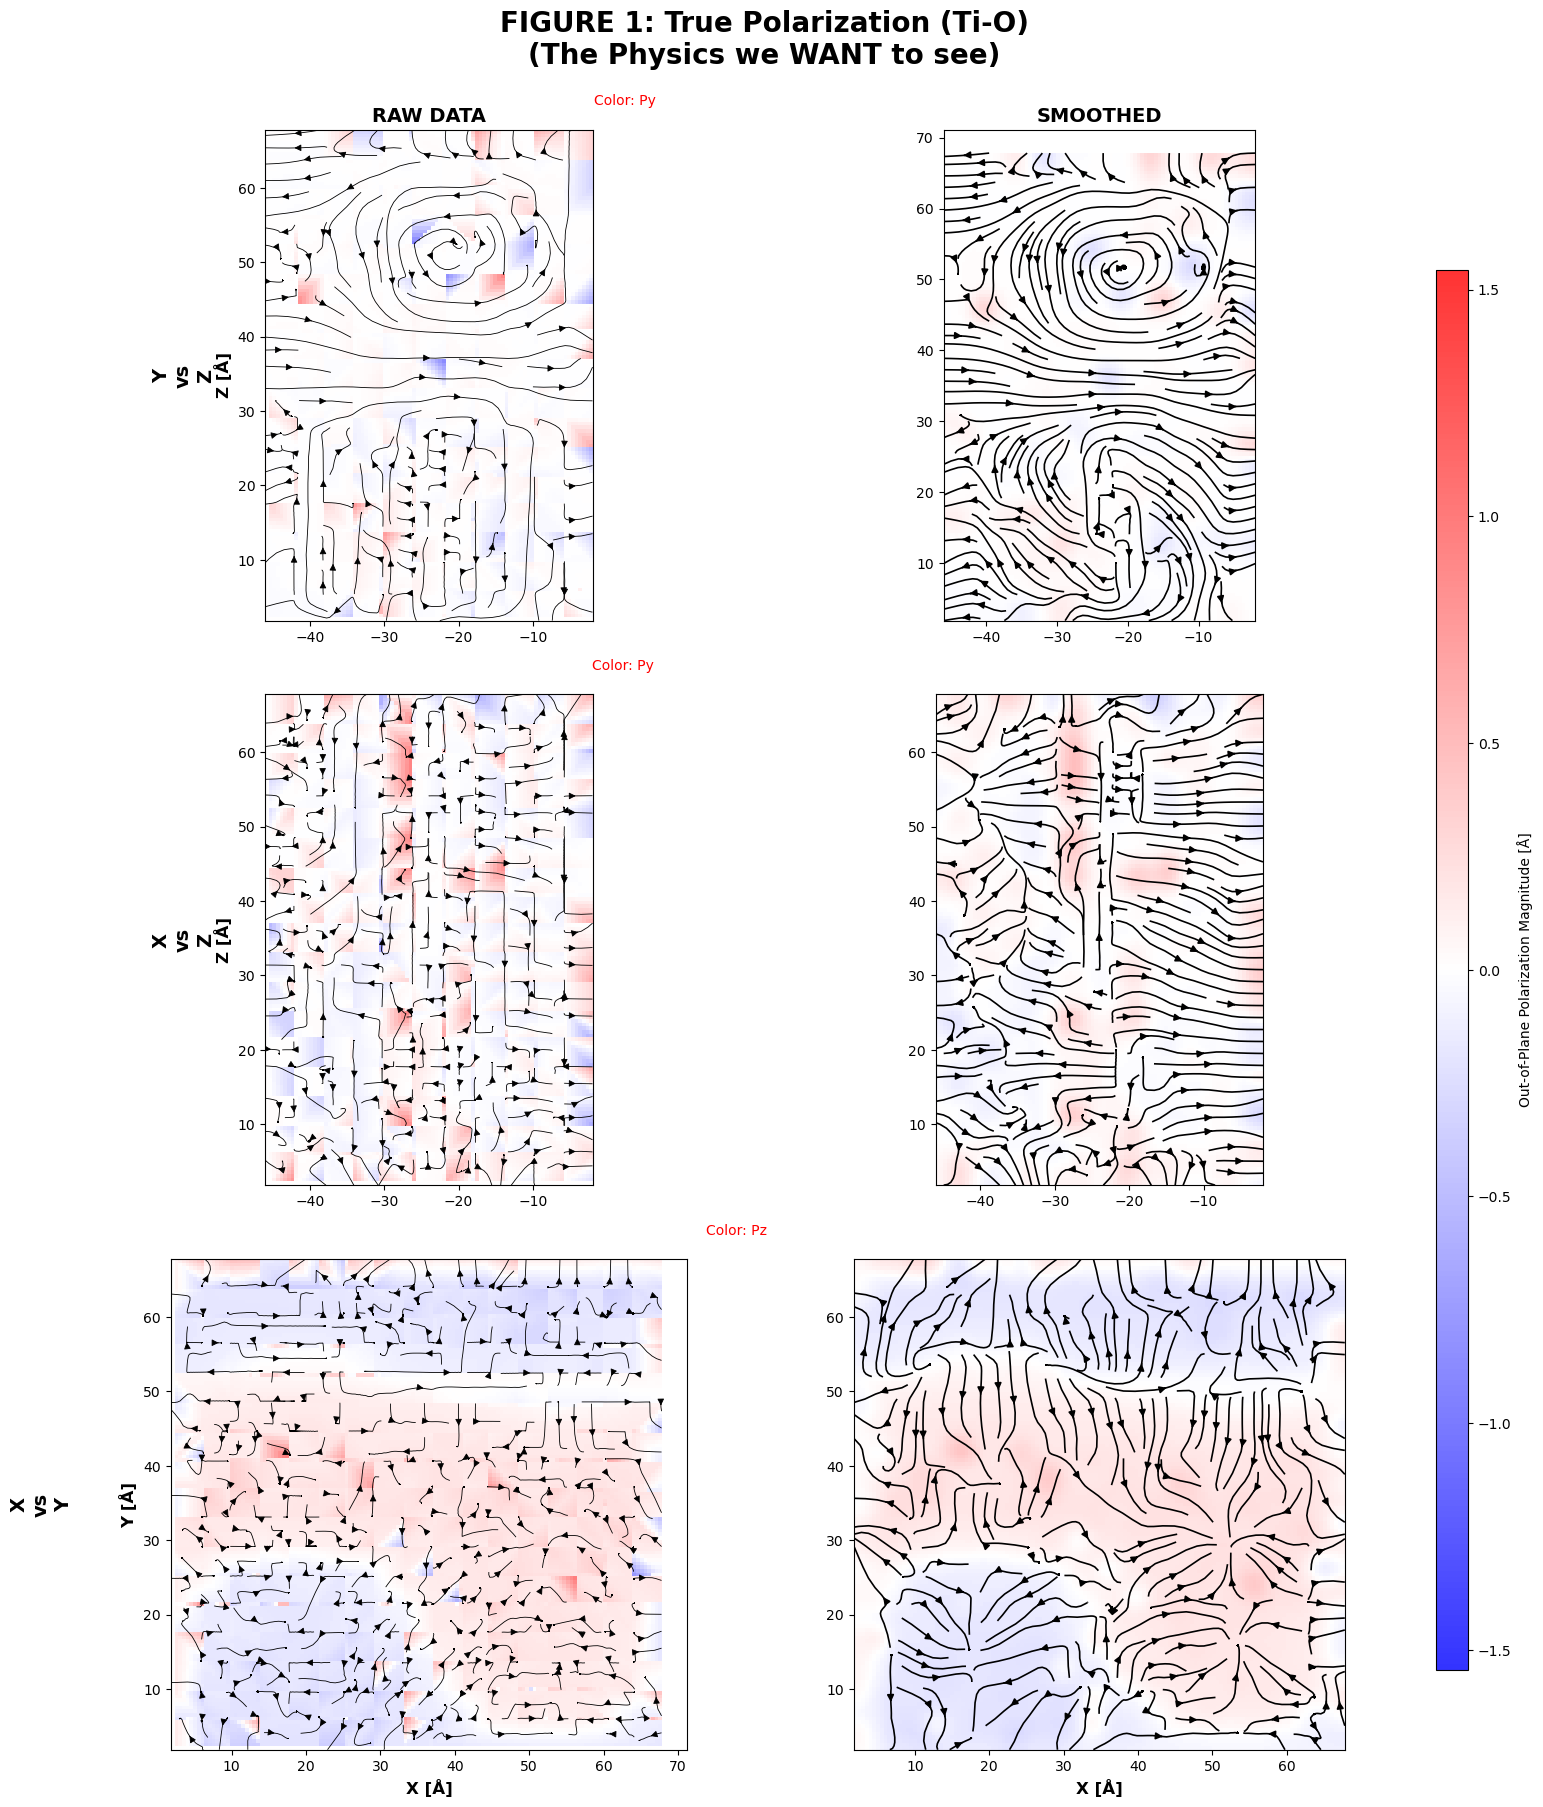

Generating Figure 2: OBSERVABLE SIGNAL (Ti-Pb)...


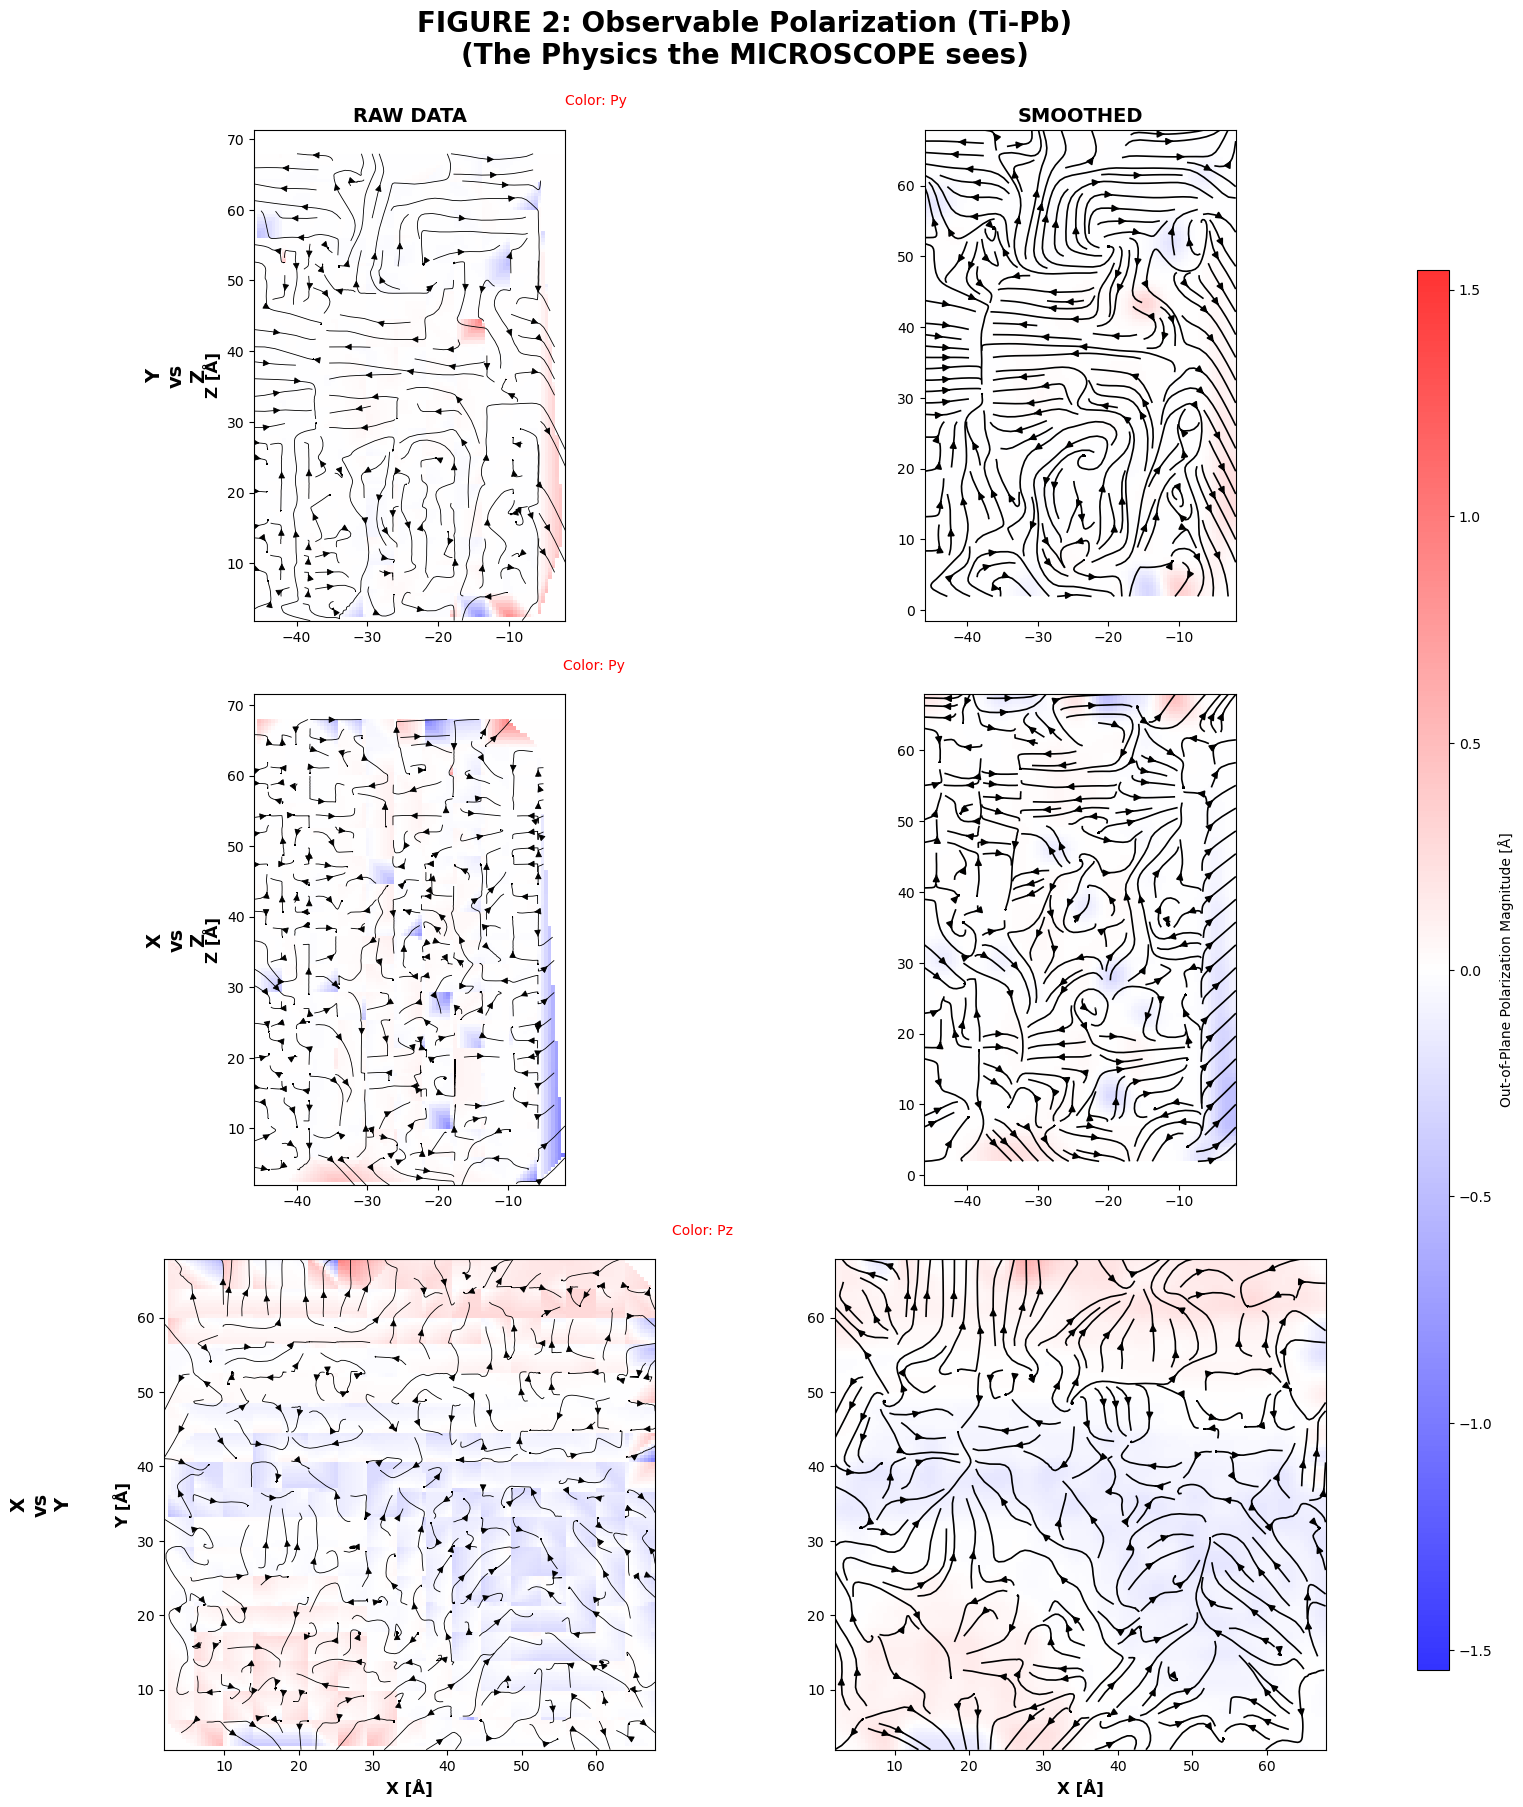

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ase.io
from scipy.spatial import KDTree
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# ==========================================
# --- 1. SETUP ---
# ==========================================
filename = 'PTO6_STO6_18_18_labyrinthPoscar.vasp'
print(f"Loading {filename}...")
atoms = ase.io.read(filename)
atoms.rotate(-90, 'y', rotate_cell=True) 
atoms.wrap()
pos = atoms.positions
syms = np.array(atoms.get_chemical_symbols())

pos_Ti = pos[syms == 'Ti']
pos_Pb = pos[np.isin(syms, ['Pb', 'Sr'])]
pos_O  = pos[syms == 'O']

# ==========================================
# --- 2. VECTOR CALCULATIONS ---
# ==========================================
print("Calculating vectors...")

def get_vectors(pos_target, cage_pos, k_neighbors, cutoff):
    tree = KDTree(cage_pos)
    vecs = []
    locs = []
    for ti in pos_target:
        dists, ind = tree.query(ti, k=k_neighbors)
        if np.mean(dists) > cutoff: continue
        cage_center = np.mean(cage_pos[ind], axis=0)
        vecs.append(ti - cage_center)
        locs.append(ti)
    return np.array(vecs), np.array(locs)

# Ti vs Oxygen (True Physics)
vec_O, pos_O_ref = get_vectors(pos_Ti, pos_O, k_neighbors=6, cutoff=2.8)

# Ti vs Pb/Sr (Observable Signal)
vec_Pb, pos_Pb_ref = get_vectors(pos_Ti, pos_Pb, k_neighbors=8, cutoff=3.8)

# ==========================================
# --- 3. GLOBAL COLOR LOCK ---
# ==========================================
# We find the maximum displacement in the Oxygen data.
# We use this to set the Red/Blue limit for BOTH figures.
limit_val = np.max(np.abs(vec_O)) 
print(f"Global Color Limit (Locked to Oxygen): +/- {limit_val:.3f} Å")

# ==========================================
# --- 4. PLOTTING FUNCTION ---
# ==========================================
def plot_comparison_figure(vectors, positions, title, filename_save):
    """Generates the 3x2 Grid (XY, XZ, YZ) x (Raw, Smooth)"""
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 20))
    
    # Define Planes: (u, v, color_component, u_label, v_label, c_label)
    planes = [
        (0, 1, 2, 'Y', 'Z', 'Py'), # 
        (0, 2, 1, 'X', 'Z',    'Py '), # 
        (2, 1, 0, 'X',    'Y', 'Pz ')  # 
    ]
    
    # Parameters
    grid_res = 0.5
    sigma = 2.5 # Smoothing factor
    
    for row, (uidx, vidx, cidx, ulab, vlab, clab) in enumerate(planes):
        # Extract Components
        U_raw = vectors[:, uidx]
        V_raw = vectors[:, vidx]
        C_raw = vectors[:, cidx]
        
        pos_u = positions[:, uidx]
        pos_v = positions[:, vidx]
        
        # Interpolate
        gu, gv = np.mgrid[pos_u.min():pos_u.max():grid_res, 
                          pos_v.min():pos_v.max():grid_res]
        
        grid_U = griddata((pos_u, pos_v), U_raw, (gu, gv), method='linear', fill_value=0)
        grid_V = griddata((pos_u, pos_v), V_raw, (gu, gv), method='linear', fill_value=0)
        grid_C = griddata((pos_u, pos_v), C_raw, (gu, gv), method='linear', fill_value=0)
        
        # Smooth
        grid_U_sm = gaussian_filter(grid_U, sigma=sigma)
        grid_V_sm = gaussian_filter(grid_V, sigma=sigma)
        grid_C_sm = gaussian_filter(grid_C, sigma=sigma)
        
        # Plot Columns
        for col in [0, 1]:
            ax = axes[row, col]
            
            # Select Data
            if col == 0:
                d_U, d_V, d_C = grid_U, grid_V, grid_C
                lbl = "RAW DATA"
            else:
                d_U, d_V, d_C = grid_U_sm, grid_V_sm, grid_C_sm
                lbl = "SMOOTHED"

            # Heatmap (Out-of-Plane)
            im = ax.imshow(d_C.T, origin='lower', extent=[gu.min(), gu.max(), gv.min(), gv.max()],
                           cmap='bwr', vmin=-limit_val, vmax=limit_val, alpha=0.8)
            
            # Streamlines (In-Plane)
            # We tune the density so Raw doesn't look like a hairball
            den = 1.0 if col == 0 else 1.4
            wid = 0.6 if col == 0 else 1.2
            
            ax.streamplot(gu.T, gv.T, d_U.T, d_V.T, color='black', linewidth=wid, 
                          arrowsize=1.0, density=den)
            
            # Labels
            if row == 0: ax.set_title(lbl, fontweight='bold', fontsize=14)
            if col == 0: 
                ax.set_ylabel(f"{vlab} [Å]", fontsize=12, fontweight='bold')
                # Add Plane Name
                ax.text(-0.25, 0.5, f"{ulab}\nvs\n{vlab}", transform=ax.transAxes, 
                        rotation=90, va='center', ha='center', fontsize=14, fontweight='bold')
                # Add Color Label
                ax.text(1.1, 1.05, f"Color: {clab}", transform=ax.transAxes, 
                        ha='center', fontsize=10, color='red')

            if row == 2: ax.set_xlabel(f"{ulab} [Å]", fontsize=12, fontweight='bold')
            
            if vlab == 'Y (Vertical)': ax.invert_yaxis()
            ax.set_aspect('equal')

    # Shared Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Out-of-Plane Polarization Magnitude [Å]")
    
    fig.suptitle(title, fontsize=20, fontweight='bold')
    plt.subplots_adjust(left=0.1, right=0.9, top=0.92, hspace=0.15, wspace=0.1)
    
    plt.show()

# ==========================================
# --- 5. EXECUTE ---
# ==========================================

print("Generating Figure 1: TRUE PHYSICS (Ti-O)...")
plot_comparison_figure(vec_O, pos_O_ref, 
                       "FIGURE 1: True Polarization (Ti-O)\n(The Physics we WANT to see)", "Ti_O_Comparison.png")

print("Generating Figure 2: OBSERVABLE SIGNAL (Ti-Pb)...")
plot_comparison_figure(vec_Pb, pos_Pb_ref, 
                       "FIGURE 2: Observable Polarization (Ti-Pb)\n(no oxygen included)", "Ti_Pb_Comparison.png")